# Modelo de Regresion Lineal con Datos Socio Demograficos y de Salud

En este cuaderno desarrollamos un analisis exploratorio completo sobre datos socio demograficos y de recursos sanitarios a nivel de condado en Estados Unidos. El objetivo es comprobar si existe una relacion util entre estas variables y un indicador de salud para despues construir modelos de regresion.

La variable objetivo elegida es `diabetes_prevalence`, porque representa un resultado de salud interpretable, frecuente en la literatura de salud publica y razonablemente conectado con factores como pobreza, educacion, envejecimiento, renta y acceso al sistema sanitario.


## Hoja de ruta del cuaderno

En este notebook vamos a seguir una secuencia parecida a la vista en clase:

1. Cargar el dataset y guardar una copia local en `data/raw`.
2. Revisar calidad del dato: dimensiones, tipos, nulos y duplicados.
3. Explorar la variable objetivo y justificar su eleccion.
4. Seleccionar variables explicativas con criterio de negocio y de interpretabilidad.
5. Ampliar el EDA con correlaciones, dispersiones y revision de outliers.
6. Dividir los datos en train y test.
7. Entrenar una regresion lineal base y un modelo Lasso.
8. Analizar como cambia el `R2` de Lasso cuando varia `alpha`.
9. Optimizar Lasso y comparar resultados.

La idea es que todo el proceso sea visible, reproducible y facil de explicar.


### Paso 1: Carga del conjunto de datos

Primero preparamos el entorno de trabajo, definimos las rutas del proyecto y cargamos el dataset. Si ya existe una copia local en `data/raw`, usamos esa version para que el cuaderno sea reproducible incluso sin depender siempre de la URL.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Silenciamos warnings numericos para que el cuaderno sea mas limpio al ejecutarlo.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Ajustamos la visualizacion general de tablas y graficos.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Detectamos la raiz del proyecto para que el notebook funcione tanto desde la raiz como desde src.
try:
    project_dir = Path.cwd().resolve()
except FileNotFoundError:
    project_dir = Path("/Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main")

if not (project_dir / "data").exists() and (project_dir.parent / "data").exists():
    project_dir = project_dir.parent

# Creamos las carpetas necesarias si no existen.
raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# Definimos la URL del proyecto y la ruta local donde guardaremos el CSV original.
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
raw_path = raw_dir / "demographic_health_data.csv"

# Si el archivo ya esta descargado, lo reutilizamos. Si no, lo descargamos y lo guardamos.
if raw_path.exists():
    total_data = pd.read_csv(raw_path)
    print(f"Dataset cargado desde archivo local: {raw_path}")
else:
    total_data = pd.read_csv(url)
    total_data.to_csv(raw_path, index=False)
    print(f"Dataset descargado desde la URL y guardado en: {raw_path}")

# Mostramos las primeras filas para entender la estructura inicial.
total_data.head()


Dataset cargado desde archivo local: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/raw/demographic_health_data.csv


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.21,7637,13.74,6878,12.37,7089,12.75,7582,13.64,7738,13.92,5826,10.48,4050,7.28,2014,3.62,42660,76.73,10915,19.63,267,0.48,681,1.22,62,0.11,1016,1.83,55601,158,455,11.80,9.60,2.20,0.00,0.70,0.60,4204,12119,10552,10291,11.30,32.60,28.40,27.70,7587,13.80,19.30,19.50,59338,53628,65048,25957,25015,942,3.60,59338,119.00,217.10,196.70,77.20,71.20,7.60,6.90,28.86,6.09,1.15,25.99,21.25,72.14,6,55036,10523,19.10,Autauga,Alabama,1,1,42438,47.60,45.40,49.40,20181,35.80,34.20,37.30,15193,7.90,7.20,8.70,3345,8.60,7.30,9.90,3644,12.90,11.90,13.80,5462,3.10,2.90,3.30,1326,3
1,1003,218022,24757,11.36,26913,12.34,23579,10.81,25213,11.56,27338,12.54,29986,13.75,29932,13.73,20936,9.60,9368,4.30,190301,87.29,19492,8.94,1684,0.77,2508,1.15,146,0.07,3891,1.78,218022,5403,2190,10.50,10.30,0.10,0.50,24.30,24.80,14310,40579,46025,46075,9.70,27.60,31.30,31.30,21069,9.80,13.90,13.10,57588,54437,60739,93849,90456,3393,3.60,57588,115.50,217.10,196.70,77.20,71.20,7.60,6.90,113.16,23.86,4.51,101.92,83.32,282.88,51,203360,53519,26.30,Baldwin,Alabama,1,3,170912,40.20,38.20,42.30,68790,29.70,28.40,31.00,50761,7.80,7.00,8.70,13414,8.60,7.20,10.10,14692,12.00,11.00,13.10,20520,3.20,3.00,3.50,5479,4
2,1005,24881,2732,10.98,2960,11.90,3268,13.13,3201,12.87,3074,12.35,3278,13.17,3076,12.36,2244,9.02,1048,4.21,12209,49.07,12042,48.40,164,0.66,113,0.45,46,0.18,307,1.23,24881,-277,2820,10.40,12.90,-2.

In [3]:
# Confirmamos la ruta del dataset en crudo y sus dimensiones generales.
print(f"Ruta del dataset en crudo: {raw_path}")
print(f"Filas y columnas: {total_data.shape}")


Ruta del dataset en crudo: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/raw/demographic_health_data.csv
Filas y columnas: (3140, 108)


### Paso 2: EDA completo

En esta fase queremos entender bien el dataset antes de modelar. Un buen EDA no solo mira graficos: tambien revisa calidad del dato, distribuciones, relaciones entre variables y posibles riesgos como multicolinealidad o fuga de informacion.

Ademas, como este proyecto quiere estudiar la relacion entre salud, contexto social y recursos sanitarios, evitaremos usar como predictores directos otras variables de resultados de salud muy cercanas a la diabetes, para no construir un modelo artificialmente facil de explicar pero poco util desde el punto de vista analitico.


In [4]:
# Revisamos cuantas observaciones y variables tenemos en total.
rows, cols = total_data.shape
print(f"El dataset contiene {rows} filas y {cols} columnas.")


El dataset contiene 3140 filas y 108 columnas.


In [5]:
# Revisamos tipos de datos, valores no nulos y memoria ocupada.
total_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [6]:
# Contamos cuantas variables numericas hay y cuantas no numericas.
numeric_columns = total_data.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_columns = total_data.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Columnas numericas: {len(numeric_columns)}")
print(f"Columnas no numericas: {len(non_numeric_columns)}")
print("Ejemplo de columnas numericas:")
print(numeric_columns[:10])


Columnas numericas: 106
Columnas no numericas: 2
Ejemplo de columnas numericas:
['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop']


In [7]:
# Resumen estadistico para detectar rangos, dispersion y posibles valores extremos.
total_data.describe().T


,count,mean,std,min,25%,50%,75%,max
fips,"3,140.00","30,401.64","15,150.56","1,001.00","18,180.50","29,178.00","45,081.50","56,045.00"
TOT_POP,"3,140.00","104,189.41","333,583.40",88.00,"10,963.25","25,800.50","67,913.00","10,105,518.00"
0-9,"3,140.00","12,740.30","41,807.30",0.00,"1,280.50","3,057.00","8,097.00","1,208,253.00"
0-9 y/o % of total pop,"3,140.00",11.87,2.12,0.00,10.59,11.80,12.95,25.46
19-Oct,"3,140.00","13,367.98","42,284.39",0.00,"1,374.50","3,274.00","8,822.25","1,239,139.00"
...,...,...,...,...,...,...,...,...
CKD_prevalence,"3,140.00",3.45,0.57,1.80,3.10,3.40,3.80,6.20
CKD_Lower 95% CI,"3,140.00",3.21,0.53,1.70,2.90,3.20,3.50,5.80
CKD_Upper 95% CI,"3,140.00",3.71,0.61,1.90,3.30,3.70,4.10,6.60
CKD_number,"3,140.00","2,466.23","7,730.42",3.00,314.75,718.00,"1,776.25","237,766.00"


In [8]:
# Buscamos valores faltantes para saber si necesitamos imputar.
missing_values = total_data.isna().sum().sort_values(ascending=False)
missing_summary = missing_values[missing_values > 0].to_frame("missing_values")
missing_summary


,missing_values


In [9]:
# Comprobamos si existen filas duplicadas exactas.
duplicated_rows = total_data.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicated_rows}")


Filas duplicadas exactas: 0


### Hallazgos de calidad del dato

En la revision inicial observamos lo siguiente:

- El dataset es esencialmente numerico, lo cual facilita el modelado de regresion.
- No aparecen valores faltantes en las variables utilizadas, por lo que no necesitamos imputaciones para este ejercicio.
- Tampoco encontramos filas duplicadas exactas, de modo que no es necesario aplicar una limpieza adicional en ese punto.

Esto nos permite centrar el resto del EDA en interpretar relaciones y seleccionar variables con sentido.


### Eleccion de la variable objetivo

Debemos elegir una variable relacionada con salud para modelarla como objetivo. En este proyecto usaremos `diabetes_prevalence` por tres motivos:

- Es una medida de salud publica clara y facil de interpretar.
- Tiene relacion plausible con factores socioeconomicos y con la disponibilidad de recursos sanitarios.
- Permite plantear una pregunta concreta: hasta que punto el entorno social y sanitario de un condado ayuda a explicar la prevalencia de diabetes.


In [10]:
# Resumimos estadisticamente la variable objetivo para entender su rango y variabilidad.
total_data["diabetes_prevalence"].describe()


count   3,140.00
mean       13.07
std         2.72
min         6.10
25%        11.20
50%        12.80
75%        14.80
max        25.60
Name: diabetes_prevalence, dtype: float64

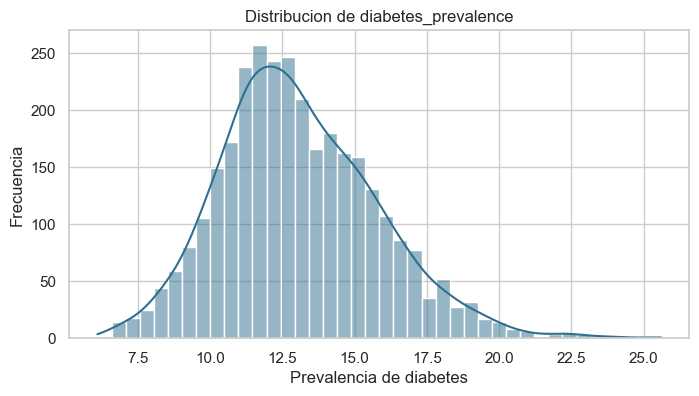

In [11]:
# Dibujamos la distribucion de la variable objetivo para ver forma, sesgo y dispersion.
plt.figure(figsize=(8, 4))
sns.histplot(total_data["diabetes_prevalence"], kde=True, color="#2f6f8f")
plt.title("Distribucion de diabetes_prevalence")
plt.xlabel("Prevalencia de diabetes")
plt.ylabel("Frecuencia")
plt.show()


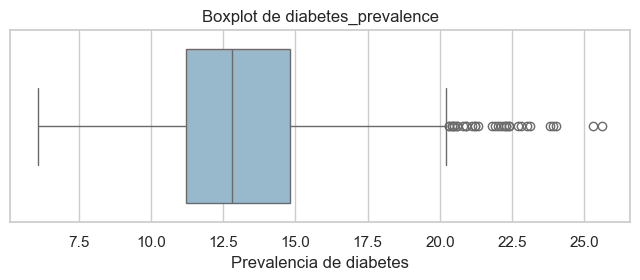

In [12]:
# Complementamos con un boxplot para detectar valores extremos de forma visual.
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=total_data["diabetes_prevalence"], color="#8fbcd4")
plt.title("Boxplot de diabetes_prevalence")
plt.xlabel("Prevalencia de diabetes")
plt.show()


### Seleccion de variables explicativas

Aunque el dataset contiene mas de cien variables, no conviene usar todas de forma automatica. Para este ejercicio nos interesa un modelo interpretable, con variables que tengan sentido desde negocio y desde salud publica.

Por eso seleccionamos un subconjunto que mezcla:

- Nivel educativo.
- Pobreza, desempleo e ingresos.
- Composicion demografica y envejecimiento.
- Recursos sanitarios disponibles en el condado.

Tambien evitamos incluir otras variables de enfermedades o resultados sanitarios muy cercanos a la diabetes, porque podrian introducir fuga de informacion o hacer menos defendible el analisis.


In [13]:
# Antes de fijar las variables del modelo, vemos que variables del dataset completo
# tienen mayor correlacion con la diabetes. Esto nos ayuda a justificar la seleccion.
target = "diabetes_prevalence"

top_target_correlations = (
    total_data.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
    .drop(labels=[target])
)

pd.concat([
    top_target_correlations.head(10).to_frame("top_positive_correlations"),
    top_target_correlations.tail(10).sort_values().to_frame("top_negative_correlations")
], axis=1)


,top_positive_correlations,top_negative_correlations
diabetes_Upper 95% CI,1.00,NaN
diabetes_Lower 95% CI,1.00,NaN
CKD_Lower 95% CI,0.92,NaN
CKD_prevalence,0.92,NaN
CKD_Upper 95% CI,0.91,NaN
anycondition_Lower 95% CI,0.86,NaN
Heart disease_Lower 95% CI,0.86,NaN
anycondition_prevalence,0.85,NaN
anycondition_Upper 95% CI,0.84,NaN
PCTPOV017_2018,0.84,NaN


In [14]:
# Definimos de forma explicita las variables explicativas que usaremos.
selected_features = [
    "Percent of adults with less than a high school diploma 2014-18",
    "Percent of adults with a high school diploma only 2014-18",
    "Percent of adults completing some college or associate's degree 2014-18",
    "Percent of adults with a bachelor's degree or higher 2014-18",
    "PCTPOVALL_2018",
    "Unemployment_rate_2018",
    "Median_Household_Income_2018",
    "% Black-alone",
    "% White-alone",
    "Percent of Population Aged 60+",
    "Active Physicians per 100000 Population 2018 (AAMC)",
    "Active Primary Care Physicians per 100000 Population 2018 (AAMC)",
    "Total nurse practitioners (2019)",
    "Total Hospitals (2019)",
    "ICU Beds_x",
    "Urban_rural_code"
]

# Construimos un dataframe mas limpio con las variables seleccionadas y la variable objetivo.
model_data = total_data[selected_features + [target]].copy()
model_data.head()


,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,Unemployment_rate_2018,Median_Household_Income_2018,% Black-alone,% White-alone,Percent of Population Aged 60+,Active Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total Hospitals (2019),ICU Beds_x,Urban_rural_code,diabetes_prevalence
0,11.30,32.60,28.40,27.70,13.80,3.60,59338,19.63,76.73,19.10,217.10,77.20,28.86,1.15,6,3,12.90
1,9.70,27.60,31.30,31.30,9.80,3.60,57588,8.94,87.29,26.30,217.10,77.20,113.16,4.51,51,4,12.00
2,27.00,35.70,25.10,12.20,30.90,5.20,34382,48.40,49.07,23.50,217.10,77.20,12.91,0.51,5,6,19.70
3,16.80,47.30,24.40,11.50,21.80,4.00,46064,21.29,76.83,21.10,217.10,77.20,11.63,0.46,0,2,14.10
4,19.80,34.00,33.50,12.60,13.20,3.50,50412,1.64,95.88,23.60,217.10,77.20,30.02,1.20,6,2,13.50


In [15]:
# Revisamos la correlacion de las variables seleccionadas con la variable objetivo.
model_data.corr(numeric_only=True)[target].sort_values(ascending=False).to_frame("correlation_with_target")


,correlation_with_target
diabetes_prevalence,1.00
PCTPOVALL_2018,0.74
Percent of adults with less than a high school diploma 2014-18,0.70
Unemployment_rate_2018,0.49
Percent of adults with a high school diploma only 2014-18,0.48
% Black-alone,0.47
Urban_rural_code,0.34
Percent of Population Aged 60+,0.26
ICU Beds_x,-0.15
Total nurse practitioners (2019),-0.19


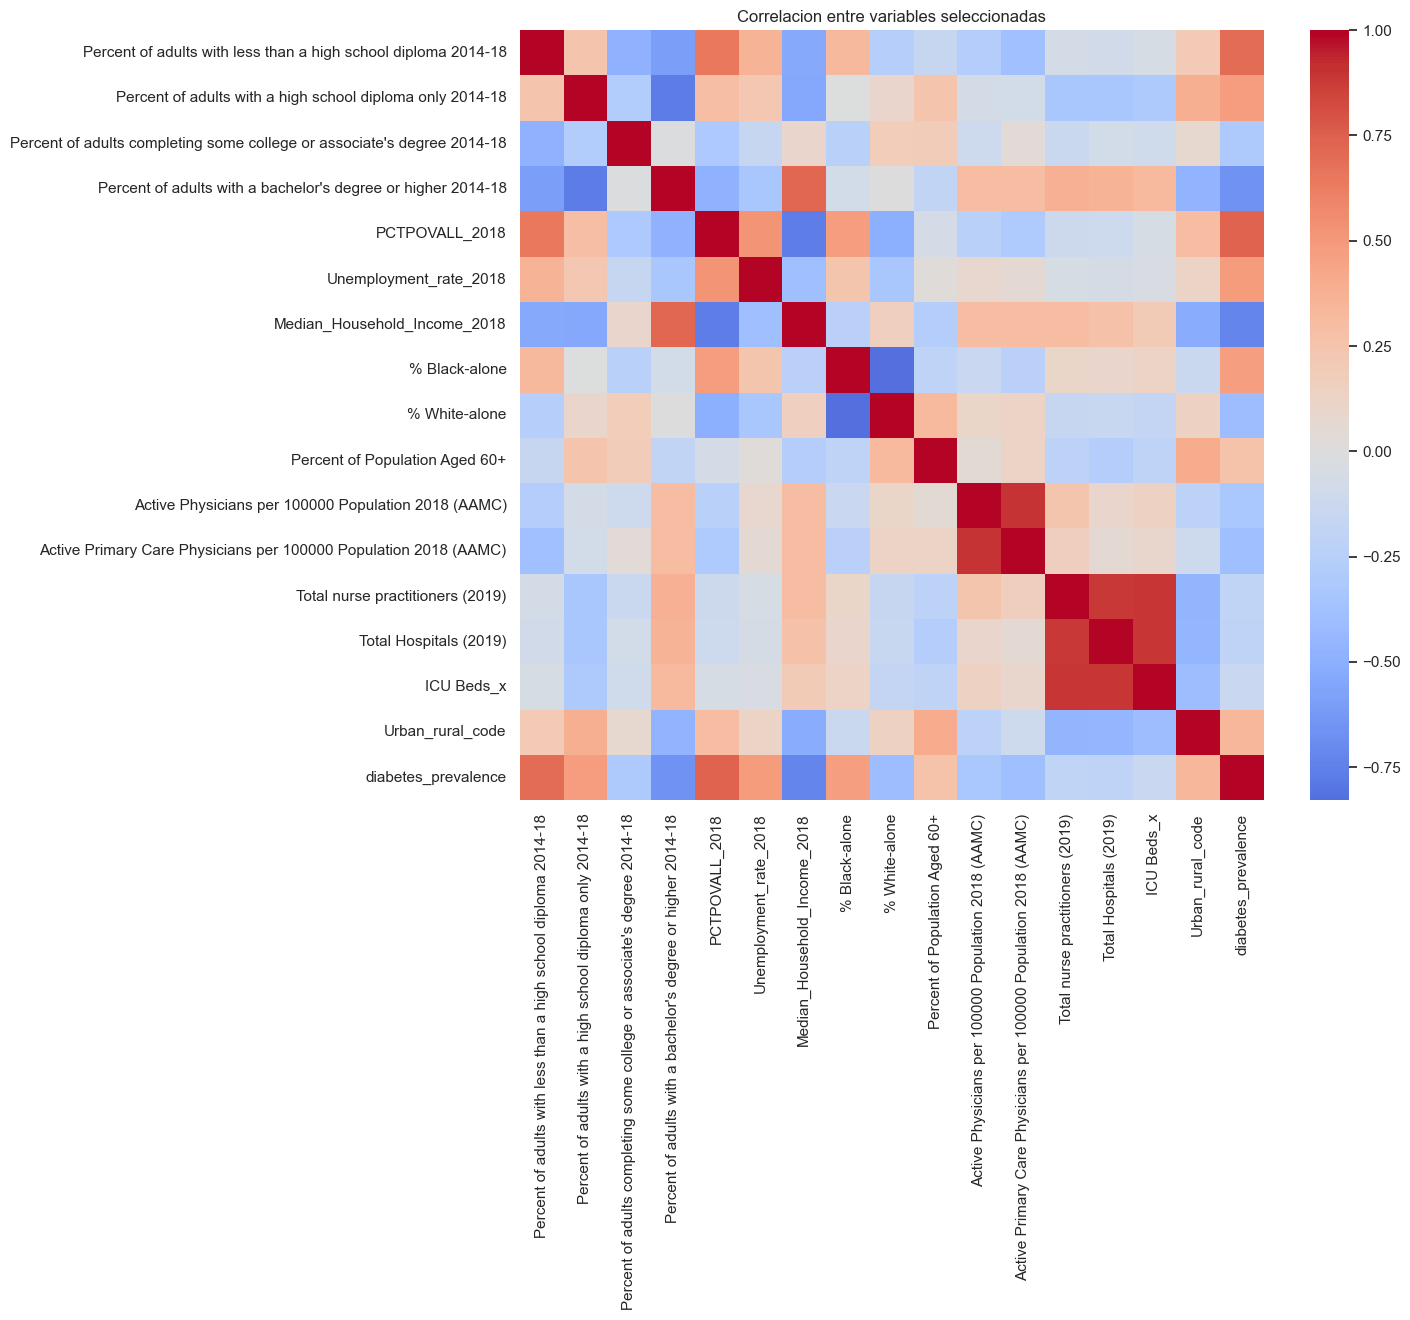

In [16]:
# Mostramos una matriz de correlacion para ver relaciones globales y posibles bloques de colinealidad.
plt.figure(figsize=(12, 10))
sns.heatmap(model_data.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlacion entre variables seleccionadas")
plt.show()


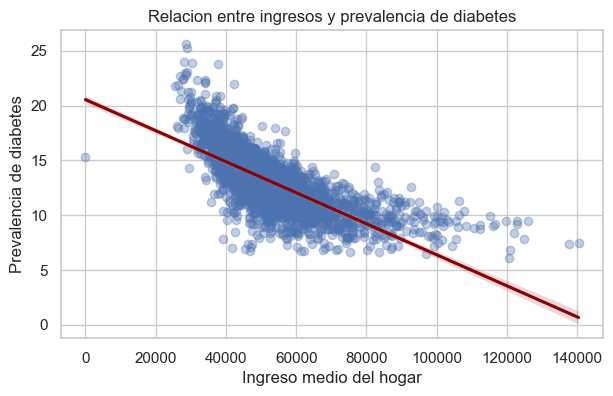

In [17]:
# Graficamos la relacion entre ingreso medio y prevalencia de diabetes.
plt.figure(figsize=(7, 4))
sns.regplot(
    data=model_data,
    x="Median_Household_Income_2018",
    y=target,
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "darkred"}
)
plt.title("Relacion entre ingresos y prevalencia de diabetes")
plt.xlabel("Ingreso medio del hogar")
plt.ylabel("Prevalencia de diabetes")
plt.show()


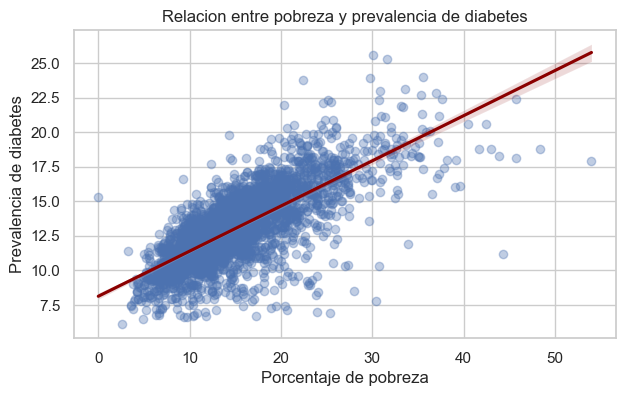

In [18]:
# Graficamos la relacion entre pobreza y prevalencia de diabetes.
plt.figure(figsize=(7, 4))
sns.regplot(
    data=model_data,
    x="PCTPOVALL_2018",
    y=target,
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "darkred"}
)
plt.title("Relacion entre pobreza y prevalencia de diabetes")
plt.xlabel("Porcentaje de pobreza")
plt.ylabel("Prevalencia de diabetes")
plt.show()


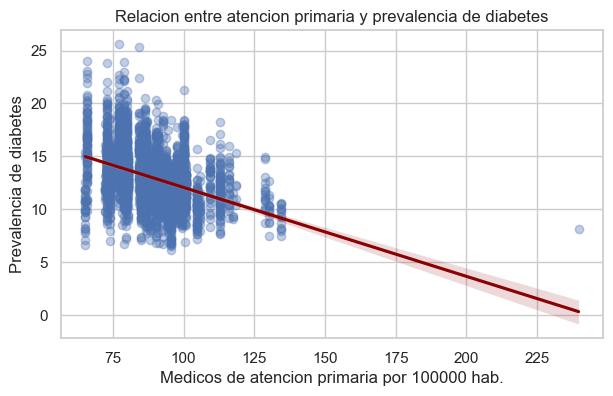

In [19]:
# Graficamos la relacion entre atencion primaria y prevalencia de diabetes.
plt.figure(figsize=(7, 4))
sns.regplot(
    data=model_data,
    x="Active Primary Care Physicians per 100000 Population 2018 (AAMC)",
    y=target,
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "darkred"}
)
plt.title("Relacion entre atencion primaria y prevalencia de diabetes")
plt.xlabel("Medicos de atencion primaria por 100000 hab.")
plt.ylabel("Prevalencia de diabetes")
plt.show()


### Revision visual de outliers

En un EDA tambien es importante revisar si hay valores muy extremos que puedan distorsionar la interpretacion o el ajuste del modelo. En este caso no vamos a eliminar outliers automaticamente, porque muchas observaciones extremas pueden representar condados reales con contextos muy distintos entre si.

Aun asi, si conviene identificarlos y documentar que existen.


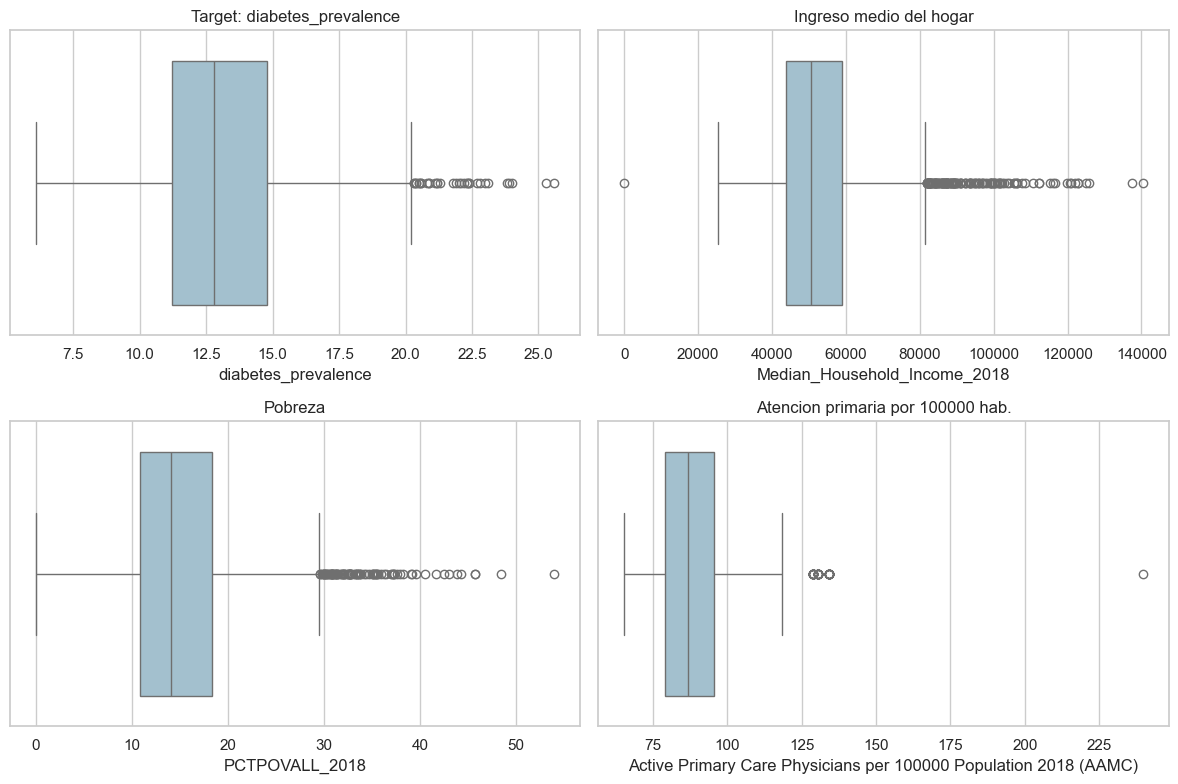

In [20]:
# Revisamos con boxplots algunas variables clave para detectar valores atipicos visibles.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x=model_data[target], ax=axes[0, 0], color="#9cc3d5")
axes[0, 0].set_title("Target: diabetes_prevalence")

sns.boxplot(x=model_data["Median_Household_Income_2018"], ax=axes[0, 1], color="#9cc3d5")
axes[0, 1].set_title("Ingreso medio del hogar")

sns.boxplot(x=model_data["PCTPOVALL_2018"], ax=axes[1, 0], color="#9cc3d5")
axes[1, 0].set_title("Pobreza")

sns.boxplot(x=model_data["Active Primary Care Physicians per 100000 Population 2018 (AAMC)"], ax=axes[1, 1], color="#9cc3d5")
axes[1, 1].set_title("Atencion primaria por 100000 hab.")

plt.tight_layout()
plt.show()


### Lectura del EDA ampliado

Hasta este punto, el analisis nos deja varias ideas utiles:

- La diabetes muestra una relacion positiva con pobreza, desempleo y menor nivel educativo.
- Variables de renta y educacion universitaria se asocian negativamente con la prevalencia de diabetes.
- Algunos recursos sanitarios, especialmente la atencion primaria, parecen relacionarse con una menor prevalencia, aunque con bastante dispersion.
- Existen valores extremos en varias variables, pero no parecen errores evidentes; tienen sentido en un dataset de condados con realidades muy diferentes.

Con este contexto, ya podemos pasar a la preparacion para el modelado.


### Preparacion para el modelo

Ahora separamos variables predictoras y variable objetivo, dividimos el dataset en entrenamiento y prueba y escalamos los predictores numericos.

Escalamos porque Lasso es sensible a la magnitud de las variables. Si no lo hacemos, variables con escalas grandes pueden dominar la penalizacion.


In [21]:
# Separamos las variables explicativas y la variable objetivo.
X = model_data.drop(columns=[target])
y = model_data[target]

# Dividimos el dataset en entrenamiento y prueba para evaluar generalizacion.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (2512, 16)
X_test shape: (628, 16)
y_train shape: (2512,)
y_test shape: (628,)


In [22]:
# Estandarizamos las variables predictoras con informacion del conjunto de entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
# Guardamos el dataset seleccionado y los conjuntos de train y test para dejar trazabilidad.
clean_path = processed_dir / "demographic_health_model_data.csv"
train_path = processed_dir / "demographic_health_train.csv"
test_path = processed_dir / "demographic_health_test.csv"

train_data = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

model_data.to_csv(clean_path, index=False)
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

print(f"Dataset procesado guardado en: {clean_path}")
print(f"Train guardado en: {train_path}")
print(f"Test guardado en: {test_path}")


Dataset procesado guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_model_data.csv
Train guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_train.csv
Test guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/demographic_health_test.csv


### Paso 3: Construccion del modelo de regresion

Empezamos con una regresion lineal base para tener una referencia clara. Despues entrenamos un modelo Lasso con sus parametros por defecto relevantes para este caso, usando una penalizacion inicial moderada.

Compararemos ambos modelos con tres metricas:

- `MAE`: error absoluto medio.
- `RMSE`: error cuadratico medio en su raiz.
- `R2`: proporcion de varianza explicada.


In [24]:
# Entrenamos la regresion lineal base.
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Generamos predicciones sobre el conjunto de prueba.
linear_pred = linear_model.predict(X_test_scaled)

# Calculamos las metricas principales del modelo base.
linear_metrics = {
    "mae": round(mean_absolute_error(y_test, linear_pred), 4),
    "rmse": round(np.sqrt(mean_squared_error(y_test, linear_pred)), 4),
    "r2": round(r2_score(y_test, linear_pred), 4)
}

linear_metrics


{'mae': 0.7753, 'rmse': np.float64(1.0176), 'r2': 0.8713}

In [25]:
# Entrenamos un modelo Lasso inicial para comparar regularizacion contra regresion lineal.
lasso_model = Lasso(alpha=0.1, max_iter=20000)
lasso_model.fit(X_train_scaled, y_train)

# Predecimos y medimos el rendimiento del modelo Lasso inicial.
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_metrics = {
    "mae": round(mean_absolute_error(y_test, lasso_pred), 4),
    "rmse": round(np.sqrt(mean_squared_error(y_test, lasso_pred)), 4),
    "r2": round(r2_score(y_test, lasso_pred), 4)
}

lasso_metrics


{'mae': 0.7995, 'rmse': np.float64(1.0535), 'r2': 0.862}

In [26]:
# Comparamos en una sola tabla la regresion lineal y el Lasso inicial.
comparison = pd.DataFrame([
    {"model": "linear_regression", **linear_metrics},
    {"model": "lasso_alpha_0.1", **lasso_metrics}
])
comparison


,model,mae,rmse,r2
0,linear_regression,0.78,1.02,0.87
1,lasso_alpha_0.1,0.80,1.05,0.86


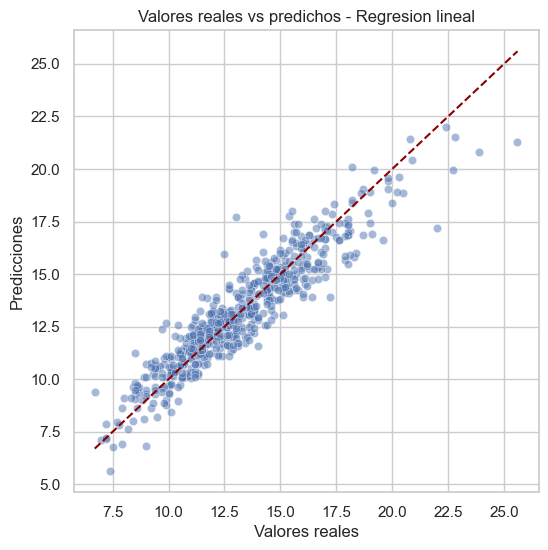

In [27]:
# Representamos valores reales frente a predicciones del modelo lineal para ver ajuste global.
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=linear_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="darkred", linestyle="--")
plt.title("Valores reales vs predichos - Regresion lineal")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.show()


### Evolucion del R2 con distintos valores de alpha

Una ventaja de Lasso es que podemos controlar la fuerza de la regularizacion mediante `alpha`. Valores pequenos suelen comportarse de forma parecida a una regresion lineal; valores grandes obligan a simplificar el modelo y pueden deteriorar el rendimiento.

Vamos a comprobarlo de forma explicita midiendo `R2` para varios valores desde `0.0` hasta `20`.


In [28]:
# Probamos diferentes valores de alpha para estudiar como cambia el rendimiento de Lasso.
alpha_values = [0.0, 0.01, 0.1, 0.5, 1, 2, 5, 10, 20]
alpha_results = []

for alpha in alpha_values:
    # Lasso no admite alpha=0 exacto, por eso usamos un valor muy pequeno como aproximacion.
    real_alpha = 0.0001 if alpha == 0.0 else alpha

    # Entrenamos, predecimos y guardamos R2 y numero de coeficientes no nulos.
    model = Lasso(alpha=real_alpha, max_iter=20000)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    alpha_results.append({
        "alpha": alpha,
        "r2": r2_score(y_test, pred),
        "non_zero_coefficients": int((model.coef_ != 0).sum())
    })

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df


,alpha,r2,non_zero_coefficients
0,0.00,0.87,16
1,0.01,0.87,12
2,0.10,0.86,10
3,0.50,0.71,7
4,1.00,0.49,4
5,2.00,-0.00,0
6,5.00,-0.00,0
7,10.00,-0.00,0
8,20.00,-0.00,0


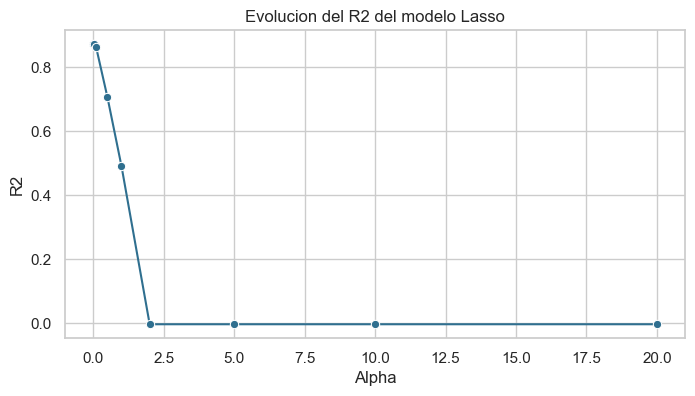

In [29]:
# Dibujamos la evolucion de R2 para visualizar donde empieza a degradarse Lasso.
plt.figure(figsize=(8, 4))
sns.lineplot(data=alpha_results_df, x="alpha", y="r2", marker="o", color="#2f6f8f")
plt.title("Evolucion del R2 del modelo Lasso")
plt.xlabel("Alpha")
plt.ylabel("R2")
plt.show()


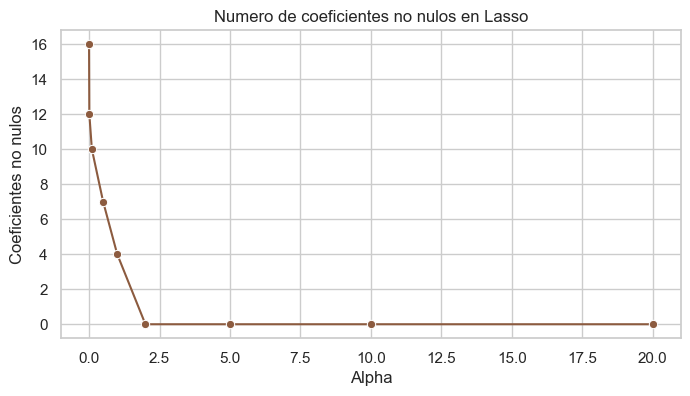

In [30]:
# Tambien miramos como cambia el numero de coeficientes activos cuando aumenta alpha.
plt.figure(figsize=(8, 4))
sns.lineplot(data=alpha_results_df, x="alpha", y="non_zero_coefficients", marker="o", color="#8c5b3f")
plt.title("Numero de coeficientes no nulos en Lasso")
plt.xlabel("Alpha")
plt.ylabel("Coeficientes no nulos")
plt.show()


### Paso 4: Optimizacion del modelo de regresion

Como el EDA del hiperparametro muestra que los mejores resultados aparecen con `alpha` bajos, hacemos una busqueda mas fina con `GridSearchCV`. De esta forma elegimos automaticamente el valor de `alpha` que mejor rinde segun `R2` en validacion cruzada.


In [31]:
# Definimos una malla de valores pequeños y medianos para refinar alpha.
param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5]
}

# Aplicamos validacion cruzada para encontrar el mejor alpha dentro de la malla.
grid_search = GridSearchCV(
    estimator=Lasso(max_iter=20000),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

grid_search.fit(X_train_scaled, y_train)
grid_search.best_params_


{'alpha': 0.001}

In [32]:
# Recuperamos el mejor modelo, predecimos y calculamos metricas finales.
optimized_lasso = grid_search.best_estimator_
optimized_pred = optimized_lasso.predict(X_test_scaled)

optimized_metrics = {
    "mae": round(mean_absolute_error(y_test, optimized_pred), 4),
    "rmse": round(np.sqrt(mean_squared_error(y_test, optimized_pred)), 4),
    "r2": round(r2_score(y_test, optimized_pred), 4)
}

optimized_metrics


{'mae': 0.7754, 'rmse': np.float64(1.0177), 'r2': 0.8712}

In [33]:
# Construimos una tabla comparativa final y la guardamos en data/processed.
final_comparison = pd.DataFrame([
    {"model": "linear_regression", **linear_metrics},
    {"model": "lasso_alpha_0.1", **lasso_metrics},
    {"model": f"lasso_optimized_alpha_{grid_search.best_params_['alpha']}", **optimized_metrics}
])

final_comparison_path = processed_dir / "regression_model_comparison.csv"
alpha_results_path = processed_dir / "lasso_alpha_results.csv"

final_comparison.to_csv(final_comparison_path, index=False)
alpha_results_df.to_csv(alpha_results_path, index=False)

print(f"Comparacion de modelos guardada en: {final_comparison_path}")
print(f"Resultados por alpha guardados en: {alpha_results_path}")
final_comparison


Comparacion de modelos guardada en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/regression_model_comparison.csv
Resultados por alpha guardados en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-Construye-un-modelo-de-regresion-lineal-usando-pandas-y-python-main/data/processed/lasso_alpha_results.csv


,model,mae,rmse,r2
0,linear_regression,0.78,1.02,0.87
1,lasso_alpha_0.1,0.80,1.05,0.86
2,lasso_optimized_alpha_0.001,0.78,1.02,0.87


In [34]:
# Ordenamos los coeficientes del Lasso optimizado para identificar variables mas influyentes.
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": optimized_lasso.coef_
})

coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients.sort_values("abs_coefficient", ascending=False).head(10).drop(columns="abs_coefficient")


,feature,coefficient
9,Percent of Population Aged 60+,1.04
0,Percent of adults with less than a high school...,1.03
8,% White-alone,-0.67
1,Percent of adults with a high school diploma o...,0.49
11,Active Primary Care Physicians per 100000 Popu...,-0.45
4,PCTPOVALL_2018,0.42
5,Unemployment_rate_2018,0.31
7,% Black-alone,0.16
15,Urban_rural_code,-0.13
6,Median_Household_Income_2018,-0.12


### Conclusiones

A partir del analisis realizado podemos defender las siguientes ideas:

- `diabetes_prevalence` es una variable objetivo adecuada porque conecta bien con factores sociales y recursos sanitarios.
- El EDA muestra una asociacion clara entre mayor prevalencia de diabetes y mayor pobreza, peor nivel educativo y mayor desempleo.
- Ingresos mas altos y mayor porcentaje de poblacion con estudios universitarios se relacionan con una menor prevalencia de diabetes.
- La regresion lineal base consigue un `R2` alto, lo que indica que este subconjunto de variables explica bien la variabilidad del objetivo.
- Lasso ofrece un rendimiento similar solo cuando `alpha` es pequeno; si la regularizacion aumenta demasiado, el modelo pierde capacidad predictiva.
- La optimizacion con `GridSearchCV` confirma que el mejor Lasso para este caso usa una penalizacion baja.

En resumen, si existe relacion entre los recursos sanitarios, el contexto socio demografico y la prevalencia de diabetes, y el modelo construido consigue capturarla de manera interpretable.
